# Final Exam BUS 458 — Loan Data Analysis
**Objective:** Your objective is to identify the key drivers of loan approval and recommend which lender should be prioritized for each customer to maximize total payout

### **Instructions**
- Follow the prompts in each section of this notebook.
- **Where you see a “Question,” answer it directly below in a Markdown (text) cell — not as a code comment.**
- Your **reasoning, interpretations, and insights** should be written in text cells, clearly separated from code.
- You are encouraged to add extra **code cells**, **visualizations**, or **short explanations** if they strengthen your analysis or help you justify decisions.
- Make sure your notebook runs cleanly from start to finish without errors.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load Data (via Google Drive or direct upload)

In [ ]:
# Add your code here
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/loan_data_analysis_final.csv')

In [ ]:
# Check first 5 rows of dataframe
# Add your code here
df.head(5)

,User ID,applications,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,00007820-89cb-4c1d-9940-eb270d605a35,1,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,00012b55-514c-421e-9c76-3300abbc1134,1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,000157c1-b6a3-4c86-82c7-9ec1bda3799a,1,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,00020400-efab-4b10-8812-2a0aaf774841,1,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,0002f737-0cda-48fb-91ed-533f3d0eab05,1,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


In [ ]:
df.tail(5)

,User ID,applications,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
99995,fffb48e8-fc77-49fe-ab4e-e99a0829a788,1,other,40000,50000.0,NaN,good,full_time,consumer_staples,5800.0,1460,0,A,0,0
99996,fffb63e2-b1d6-4d73-b766-44ba50203c00,1,major_purchase,70000,79000.0,621.0,fair,full_time,consumer_staples,5691.0,2705,0,B,0,0
99997,fffba42b-265f-4269-a6d5-c8db7e3bd430,1,major_purchase,80000,96000.0,NaN,poor,full_time,real_estate,3312.0,1210,0,C,0,0
99998,fffd8e45-d5f8-4b06-b1a4-2d4bf527ee51,1,debt_conslidation,90000,109000.0,NaN,poor,full_time,industrials,4597.0,1420,0,C,0,0
99999,fffe836d-3176-4766-81c0-8812d1d9a0a6,1,other,50000,57000.0,NaN,poor,full_time,materials,2533.0,2648,0,A,0,0


In [ ]:
# Drop columns that have no variation or are unique
# Add your code here
df.columns

Index(['User ID', 'applications', 'Reason', 'Granted_Loan_Amount',
       'Requested_Loan_Amount', 'FICO_score', 'Fico_Score_group',
       'Employment_Status', 'Employment_Sector', 'Monthly_Gross_Income',
       'Monthly_Housing_Payment', 'Ever_Bankrupt_or_Foreclose', 'Lender',
       'Approved', 'bounty'],
      dtype='object')

In [ ]:
print(df['applications'].unique())

[1]


In [ ]:
print(df['Employment_Status'].unique())

['full_time' 'part_time' 'unemployed']


In [ ]:
print(df['Ever_Bankrupt_or_Foreclose'].unique())

[0 1]


In [ ]:
print(df['Fico_Score_group'].unique())

['fair' 'poor' 'good' 'very_good' 'excellent']


In [ ]:
## drop applications (no variation) and userid (unique) columns
df = df.drop(columns=['User ID', 'applications'])

In [ ]:
# Verify the columns have been dropped
display(df.head())

,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


Understand the Data: Get a quick overview of the dataset structure and variable meanings before preprocessing.

In [ ]:
# Add your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Reason                      100000 non-null  object 
 1   Granted_Loan_Amount         100000 non-null  int64  
 2   Requested_Loan_Amount       100000 non-null  float64
 3   FICO_score                  85000 non-null   float64
 4   Fico_Score_group            100000 non-null  object 
 5   Employment_Status           100000 non-null  object 
 6   Employment_Sector           93593 non-null   object 
 7   Monthly_Gross_Income        85000 non-null   float64
 8   Monthly_Housing_Payment     100000 non-null  int64  
 9   Ever_Bankrupt_or_Foreclose  100000 non-null  int64  
 10  Lender                      100000 non-null  object 
 11  Approved                    100000 non-null  int64  
 12  bounty                      100000 non-null  int64  
dtypes: float64(3), 

In [ ]:
df.shape

(100000, 13)

In [ ]:
df.head(10)

,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0
5,other,30000,32000.0,565.0,poor,full_time,consumer_staples,8061.0,658,0,C,0,0
6,other,80000,89000.0,691.0,good,full_time,communication_services,NaN,1289,0,A,1,250
7,debt_conslidation,70000,78000.0,715.0,good,full_time,materials,7405.0,1985,0,B,0,0
8,major_purchase,40000,48000.0,634.0,fair,full_time,utilities,4394.0,891,0,A,0,0
9,debt_conslidation,90000,97000.0,661.0,fair,part_time,energy,2175.0,626,0,A,0,0


In [ ]:
df.tail(10)

,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
99990,debt_conslidation,30000,32000.0,553.0,poor,full_time,health_care,4676.0,1144,0,A,0,0
99991,credit_card_refinancing,30000,32000.0,701.0,good,full_time,real_estate,NaN,1376,0,A,1,250
99992,cover_an_unexpected_cost,40000,43000.0,678.0,good,full_time,industrials,6979.0,1894,0,A,0,0
99993,debt_conslidation,20000,24000.0,575.0,poor,part_time,health_care,4947.0,1217,0,A,0,0
99994,major_purchase,10000,12000.0,537.0,poor,full_time,utilities,5367.0,2731,0,B,0,0
99995,other,40000,50000.0,NaN,good,full_time,consumer_staples,5800.0,1460,0,A,0,0
99996,major_purchase,70000,79000.0,621.0,fair,full_time,consumer_staples,5691.0,2705,0,B,0,0
99997,major_purchase,80000,96000.0,NaN,poor,full_time,real_estate,3312.0,1210,0,C,0,0
99998,debt_conslidation,90000,109000.0,NaN,poor,full_time,industrials,4597.0,1420,0,C,0,0
99999,other,50000,57000.0,NaN,poor,full_time,materials,2533.0,2648,0,A,0,0


<Axes: xlabel='Approved', ylabel='count'>

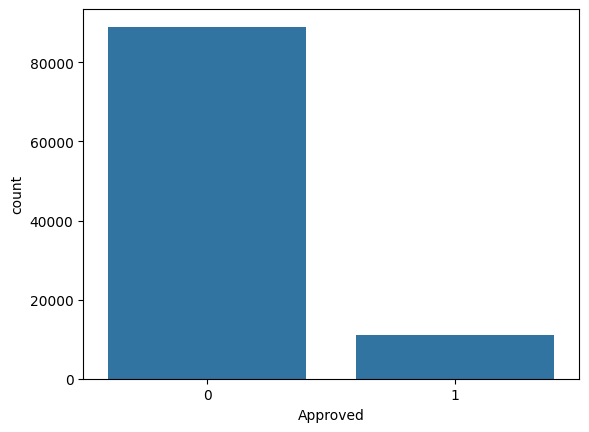

In [ ]:
import seaborn as sns
sns.countplot(x=df.Approved)

### Descriptive Statistics for Numerical Variables

In [ ]:
# Summary statistics for numerical columns
display(df.describe())

,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Approved,bounty
count,1.000000e+05,1.000000e+05,85000.000000,85000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.478465e+04,7.450309e+04,629.338153,5808.783776,1888.900720,0.022460,0.109760,26.415000
std,1.965837e+05,2.264856e+05,88.684201,2988.185274,3431.924282,0.148175,0.312592,78.385644
min,5.000000e+03,5.000000e+03,300.000000,-17702.000000,300.000000,0.000000,0.000000,0.000000
25%,2.000000e+04,2.400000e+04,572.000000,3659.000000,1231.000000,0.000000,0.000000,0.000000
50%,4.000000e+04,4.400000e+04,634.000000,5153.500000,1669.000000,0.000000,0.000000,0.000000
75%,7.000000e+04,8.400000e+04,693.000000,7612.000000,2051.000000,0.000000,0.000000,0.000000
max,2.000000e+06,2.500000e+06,850.000000,19997.000000,49500.000000,1.000000,1.000000,350.000000


### Frequency Counts for Categorical Variables

---



In [ ]:
# Select categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Loop through each categorical column and display value counts
for col in categorical_cols:
    print(f"\nValue counts for column: {col}")
    display(df[col].value_counts())


Value counts for column: Reason


,count
Reason,
debt_conslidation,27622
cover_an_unexpected_cost,18782
credit_card_refinancing,17139
major_purchase,16023
home_improvement,11316
other,9118



Value counts for column: Fico_Score_group


,count
Fico_Score_group,
fair,36475
poor,28475
good,27760
very_good,5102
excellent,2188



Value counts for column: Employment_Status


,count
Employment_Status,
full_time,76530
part_time,17064
unemployed,6406



Value counts for column: Employment_Sector


,count
Employment_Sector,
information_technology,19748
health_care,12403
real_estate,9297
financials,9262
consumer_staples,8974
industrials,7559
materials,6748
communication_services,6655
energy,5264



Value counts for column: Lender


,count
Lender,
A,55000
B,27500
C,17500


## 1. Preprocessing


### 1.1 Handling Missing Values

**Question:** Why is median imputation often preferable to mean imputation for income and FICO?


**Answer:** This is because there can easily be outliers in the data, causing it to be skewed one way or the other. With income and FICO score, a few really high incomes that are uncharacteristic or one or two really low FICO scores can misrepresent the true meaning of the data.





In [ ]:
# Inspect missing values
# Add your code here
df.isna().sum()

,0
Reason,0
Granted_Loan_Amount,0
Requested_Loan_Amount,0
FICO_score,15000
Fico_Score_group,0
Employment_Status,0
Employment_Sector,6407
Monthly_Gross_Income,15000
Monthly_Housing_Payment,0
Ever_Bankrupt_or_Foreclose,0


In [ ]:
# Select categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Loop through each categorical column and display value counts
for col in categorical_cols:
    print(f"\nValue counts for column: {col}")
    display(df[col].value_counts())


Value counts for column: Reason


,count
Reason,
debt_conslidation,27622
cover_an_unexpected_cost,18782
credit_card_refinancing,17139
major_purchase,16023
home_improvement,11316
other,9118



Value counts for column: Fico_Score_group


,count
Fico_Score_group,
fair,36475
poor,28475
good,27760
very_good,5102
excellent,2188



Value counts for column: Employment_Status


,count
Employment_Status,
full_time,76530
part_time,17064
unemployed,6406



Value counts for column: Employment_Sector


,count
Employment_Sector,
information_technology,19748
health_care,12403
real_estate,9297
financials,9262
consumer_staples,8974
industrials,7559
materials,6748
communication_services,6655
energy,5264



Value counts for column: Lender


,count
Lender,
A,55000
B,27500
C,17500


In [ ]:
# Apply imputation as instructed in the instructions pdf (create copies so original rows can be restored if needed)

# Impute
# Add your code here

# Display missing values BEFORE imputation
print("Missing values BEFORE imputation:")
display(df.isna().sum())

# Create a copy of the DataFrame to preserve the original
df_imputed = df.copy()

# Impute FICO_score and Monthly_Gross_Income with their medians
median_fico = df_imputed['FICO_score'].median()
median_gross_income = df_imputed['Monthly_Gross_Income'].median()
df_imputed['FICO_score'].fillna(median_fico, inplace=True)
df_imputed['Monthly_Gross_Income'].fillna(median_gross_income, inplace=True)

# Impute Employment_Sector with its mode
mode_employment_sector = df_imputed['Employment_Sector'].mode()[0]
df_imputed['Employment_Sector'].fillna(mode_employment_sector, inplace=True)

# Display missing values AFTER imputation
print("\nMissing values AFTER imputation:")
display(df_imputed.isna().sum())

Missing values BEFORE imputation:


,0
Reason,0
Granted_Loan_Amount,0
Requested_Loan_Amount,0
FICO_score,15000
Fico_Score_group,0
Employment_Status,0
Employment_Sector,6407
Monthly_Gross_Income,15000
Monthly_Housing_Payment,0
Ever_Bankrupt_or_Foreclose,0



Missing values AFTER imputation:


/tmp/ipykernel_6173/3662876538.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed['FICO_score'].fillna(median_fico, inplace=True)
/tmp/ipykernel_6173/3662876538.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,0
Reason,0
Granted_Loan_Amount,0
Requested_Loan_Amount,0
FICO_score,0
Fico_Score_group,0
Employment_Status,0
Employment_Sector,0
Monthly_Gross_Income,0
Monthly_Housing_Payment,0
Ever_Bankrupt_or_Foreclose,0


### 1.2 Outliers Detection and Removal

**Question:**
Which features had the most outliers, and what impact could they have on the model?

**Answer:** Monthly Gross Income and Granted_Loan_Amount seemed to have the most outliers, along with Requested Loan Amount, which could make them less predictive, as outliers take away a good bit of the consistency we want for predicting. This can affect the mean of the values, either bringing it too high or too low based on the rest of the data.

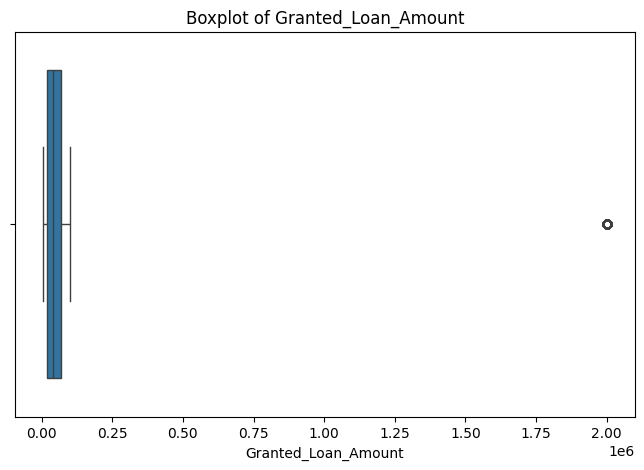

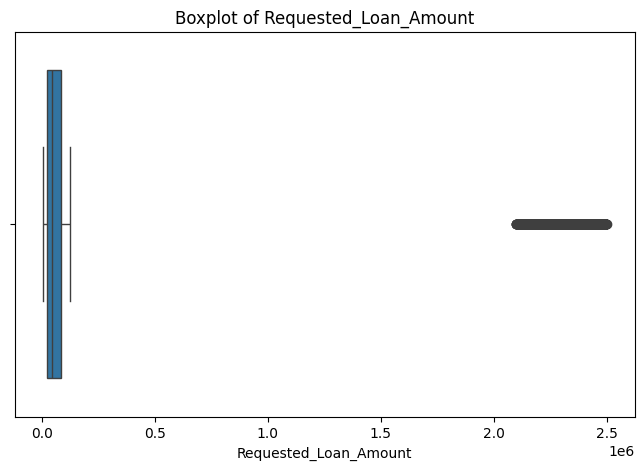

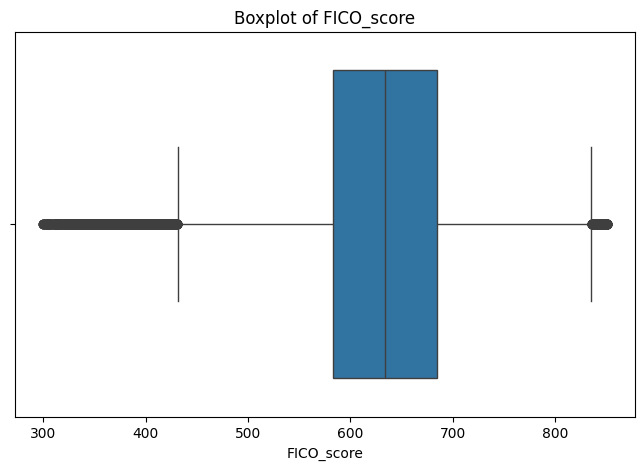

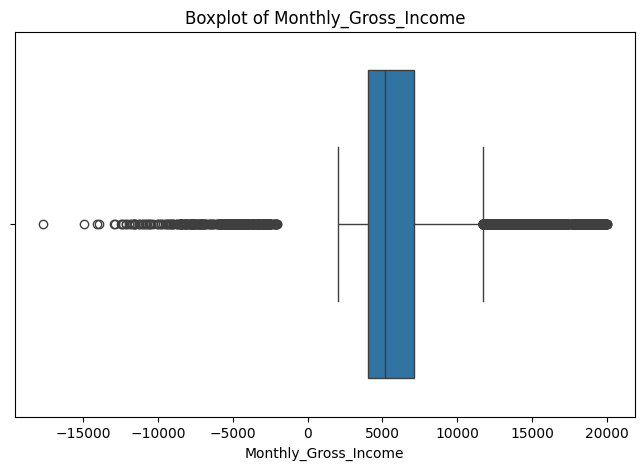

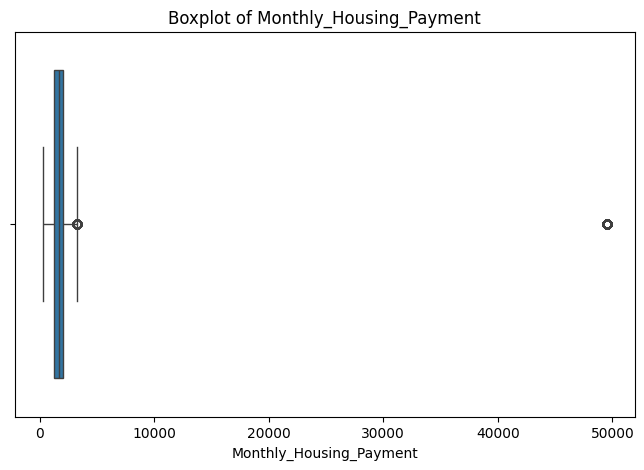

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Boxplots to highlight outliers for numerical columns
# Add your code here
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df_imputed[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [ ]:
import numpy as np
from scipy import stats

# Ensure numeric_cols is defined for robustness
numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Compute Z-scores for the numeric columns in df_imputed (before outlier removal)
z_scores = np.abs(stats.zscore(df_imputed[numeric_cols], nan_policy='omit'))

# Choose threshold for outlier detection
threshold = 3

# Identify rows to keep (all Z-scores <= threshold) for calculating total outliers
rows_to_keep = (z_scores < threshold).all(axis=1)

print("Outlier count per feature (based on Z-score > 3):")
for i, col in enumerate(numeric_cols):
    # Identify rows where the Z-score for the specific column exceeds the threshold
    # Using the boolean array for z_scores, so no need for np.nansum directly on feature_outliers if it's already boolean.
    feature_outliers_count = np.sum(z_scores[:, i] >= threshold)
    print(f"{col}: {int(feature_outliers_count)}")

total_outliers = (~rows_to_keep).sum()
print(f"\nTotal number of rows with at least one outlier detected across all features: {total_outliers}")

Outlier count per feature (based on Z-score > 3):
Granted_Loan_Amount: 1000
Requested_Loan_Amount: 1000
FICO_score: 1071
Monthly_Gross_Income: 1794
Monthly_Housing_Payment: 500

Total number of rows with at least one outlier detected across all features: 4309


In [ ]:
df.shape

(100000, 13)

In [ ]:
# Remove Outliers using Z-score

from scipy import stats
import numpy as np

# Compute Z-scores for only numeric columns
# Ensure 'numeric_cols' is defined if it's not global or already defined in this cell context
numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment'] # Redefine for robustness if it was a problem

z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Choose threshold
threshold = 3  # common choice: 3 standard deviations

# Identify rows to keep (all Z-scores <= threshold)
rows_to_keep = (z_scores < threshold).all(axis=1)

# Track counts before/after
before_count = df.shape[0]
df_clean = df[rows_to_keep].copy()
after_count = df_clean.shape[0]

print(f"Outlier removal complete:")
print(f"Rows before: {before_count}")
print(f"Rows after:  {after_count}")
print(f"Rows removed: {before_count - after_count}")

Outlier removal complete:
Rows before: 100000
Rows after:  69831
Rows removed: 30169


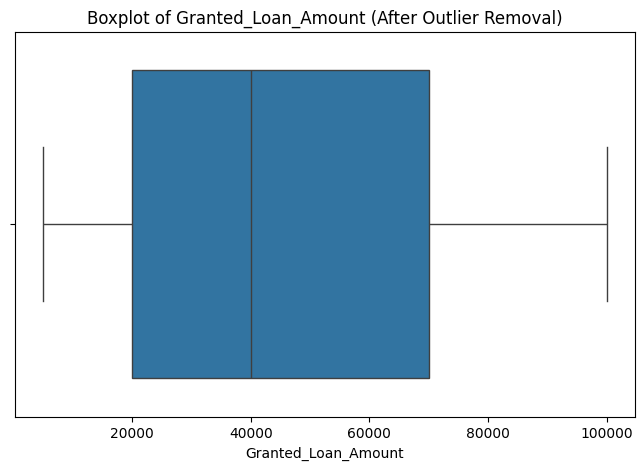

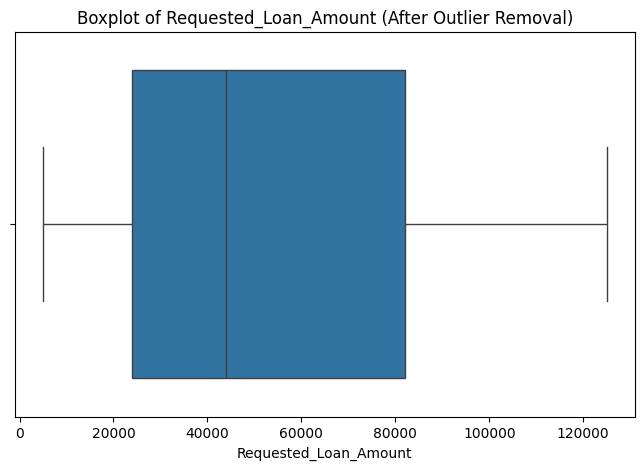

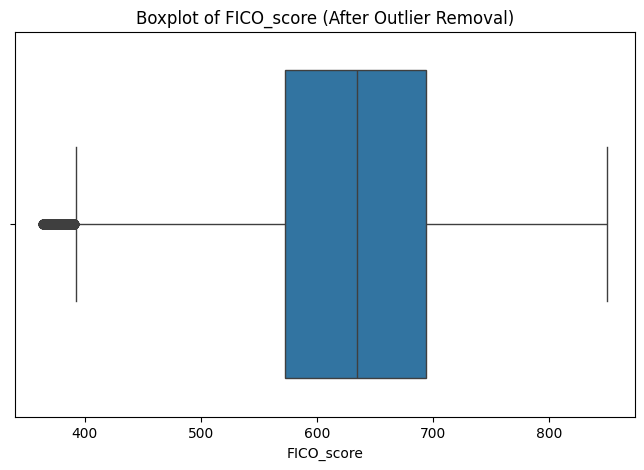

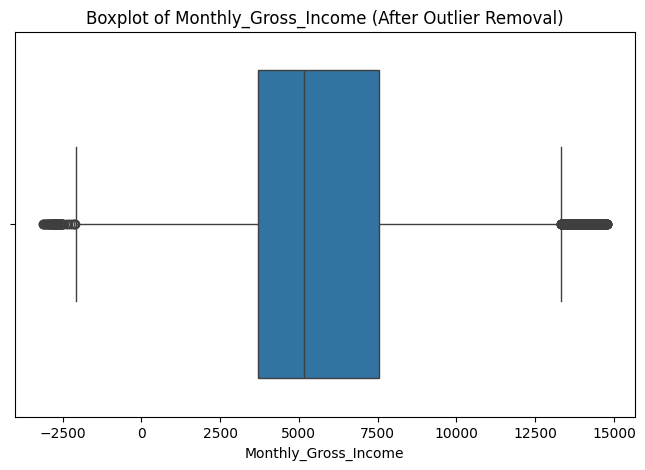

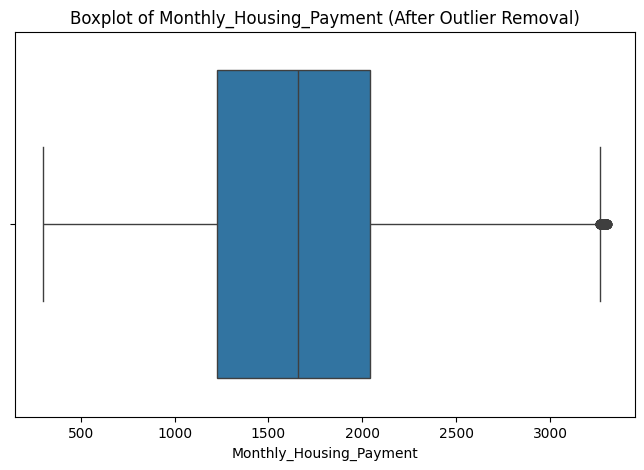

In [ ]:
# BoxPlots after outlier removal
# Add your code here
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col} (After Outlier Removal)')
    plt.xlabel(col)
    plt.show()

**Question:**
Why do we need to remove or treat outliers? Provide reasoning based on model performance or data integrity.

**Answer** : It will make the data more accurate, getting rid of the values that skew our data. If we have a lot of outliers, our data will be skewed either too far to the right or the left (depending on where the outliers are).The model will predict on data that is not representative of the truth.


**Question:**
Is there a difference between boxplots before and after outlier removal?

**Answer** : There is definitely a difference. There are far less outliers. The boxes are also a lot wider, indicating that the scale has gotten smaller, which means our plots have gotten more precise.

### 1.3 Redundancy & Correlation Check (5 Marks)

Detect duplicate data and multicollinearity.

**Question:**
Which numerical variables appear most strongly correlated with each other?

**Answer:** FICO score is fairly closely correlated with Monthly Gross Income and the Approved variables. Monthly Gross income is also (a little less) fairly correlated with Monthly Housing Payment and Approved.



**Question:**
Which numerical and categorical are strongly corelated to each other?

**Answer:** FICO Score Group and FICO score are very strongly correlated at .92. This is a fairly accurate number and a good sign. Monthly Gross Income and Employment Status are also fairly correlated at 0.53. The last fairly high number is 0.31, the correlation between monthly gross income and FICO Score Group.


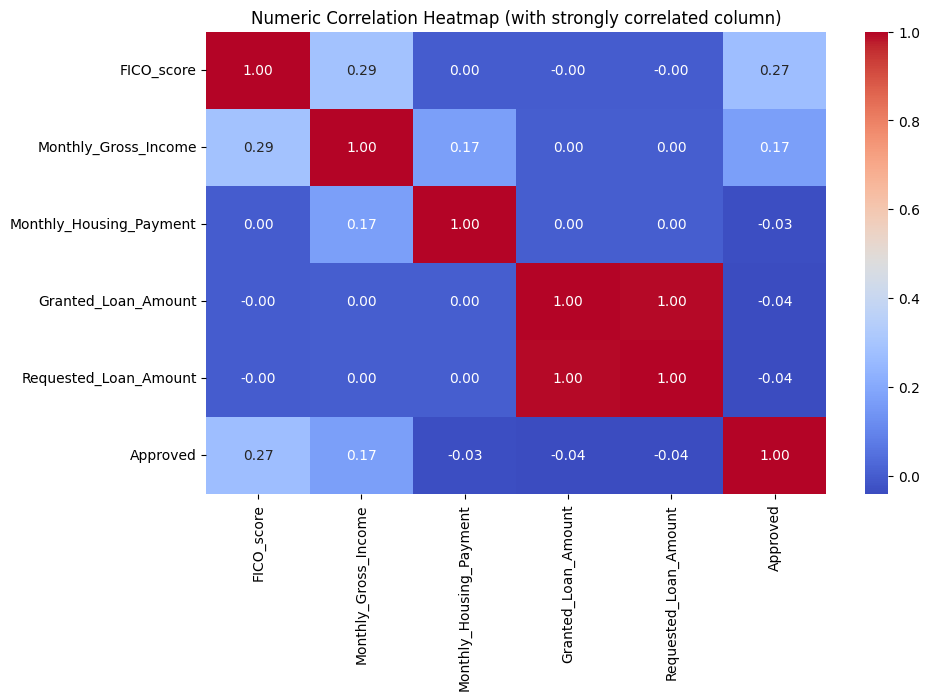

In [ ]:
# Correlation between numerical features
numeric_cols = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Granted_Loan_Amount','Requested_Loan_Amount', 'Approved']

# Plot correlation matrix, identify highly correlated pairs automatically (|corr|>0.95, excluding self-correlation)
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Numeric Correlation Heatmap (with strongly correlated column)")
plt.show()


Top 10 Numeric-Categorical Correlation Ratios (η²):
FICO_score - Fico_Score_group: η² = 0.850 (η = 0.922)
Monthly_Gross_Income - Employment_Status: η² = 0.282 (η = 0.531)
Monthly_Gross_Income - Fico_Score_group: η² = 0.095 (η = 0.308)
Monthly_Housing_Payment - Employment_Status: η² = 0.040 (η = 0.199)
Ever_Bankrupt_or_Foreclose - Employment_Status: η² = 0.030 (η = 0.174)
Monthly_Housing_Payment - Lender: η² = 0.028 (η = 0.167)
Monthly_Gross_Income - Employment_Sector: η² = 0.019 (η = 0.137)
Monthly_Gross_Income - Lender: η² = 0.009 (η = 0.096)
Ever_Bankrupt_or_Foreclose - Lender: η² = 0.005 (η = 0.070)
Ever_Bankrupt_or_Foreclose - Employment_Sector: η² = 0.005 (η = 0.070)


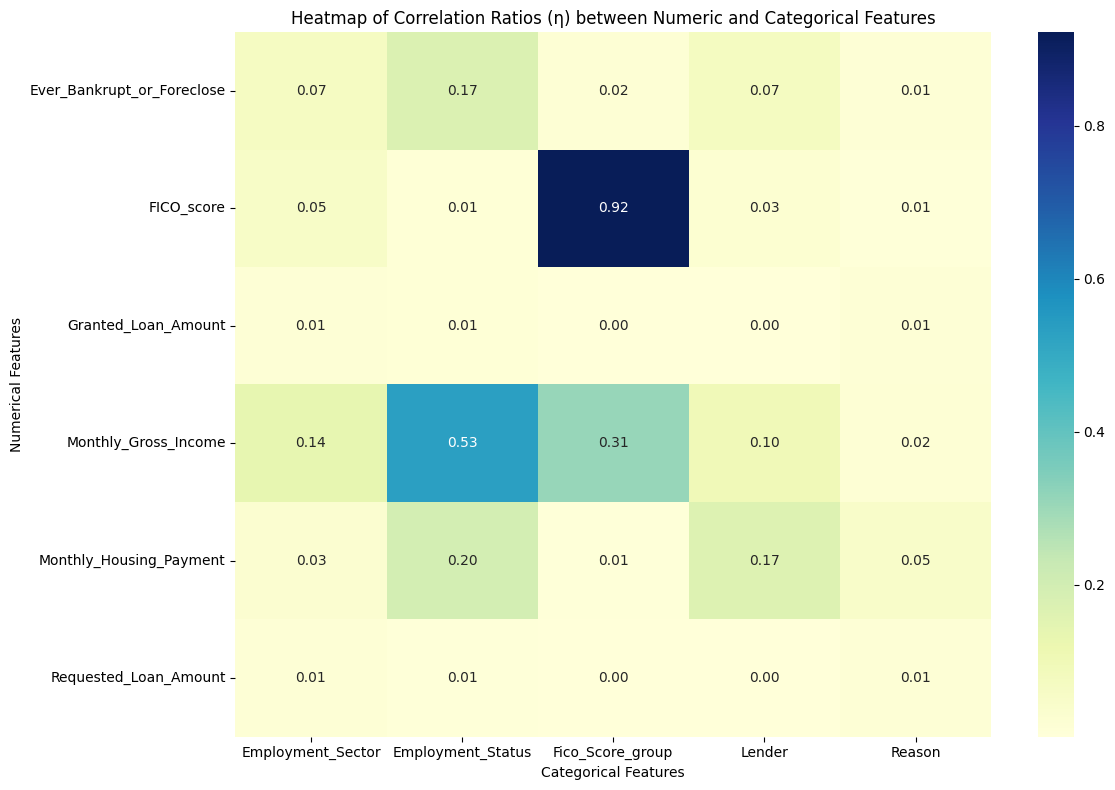

In [ ]:
# Correlation between Numeric and Categorical Variables (Correlation Ratio / η²)
from scipy import stats

def correlation_ratio(categories, values):
    categories = np.array(categories)
    values = np.array(values)
    # Filter out NaNs from categories before finding unique levels
    valid_categories = categories[~pd.isnull(categories)]
    if len(valid_categories) == 0:
        return 0 # No valid categories to compute ratio
    cat_levels = np.unique(valid_categories)

    overall_mean = np.mean(values)
    numerator = sum(len(values[categories == cat]) *
                    (np.mean(values[categories == cat]) - overall_mean) ** 2
                    for cat in cat_levels)
    denominator = sum((values - overall_mean) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# test all numeric–categorical pairs
num_cat_results = []


# Identify categorical and numerical columns
categorical_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
numeric_cols_clean = df_clean.select_dtypes(include=np.number).columns.tolist()

# Impute missing values in Employment_Sector for df_clean before using it
# as the correlation_ratio function expects clean categories.
mode_employment_sector_clean = df_clean['Employment_Sector'].mode()[0]
df_clean['Employment_Sector'] = df_clean['Employment_Sector'].fillna(mode_employment_sector_clean)


numeric_cols_for_eta = [col for col in numeric_cols_clean if col not in ['bounty', 'Approved', ]] # Exclude 'bounty' and 'Approved' as they are target/related variables
categorical_cols_for_eta = [col for col in categorical_cols_clean]


for num_col in numeric_cols_for_eta:
    for cat_col in categorical_cols_for_eta:
        eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
        num_cat_results.append((num_col, cat_col, eta))

num_cat_results = sorted(num_cat_results, key=lambda x: x[2], reverse=True)
print("Top 10 Numeric-Categorical Correlation Ratios (η²):")
for num_col, cat_col, eta in num_cat_results[:10]:
    print(f"{num_col} - {cat_col}: η² = {eta**2:.3f} (η = {eta:.3f})")


# Reorganize the correlation ratio results into a pivot table/matrix for heatmap
eta_matrix = pd.DataFrame(num_cat_results, columns=['Numerical_Feature', 'Categorical_Feature', 'Eta'])
eta_pivot = eta_matrix.pivot(index='Numerical_Feature', columns='Categorical_Feature', values='Eta')

# Plot the heatmap of correlation ratios (Eta)
plt.figure(figsize=(12, 8))
sns.heatmap(eta_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Correlation Ratios (η) between Numeric and Categorical Features")
plt.xlabel("Categorical Features")
plt.ylabel("Numerical Features")
plt.tight_layout()
plt.show()

**Questions:** What features will you consider dropping after analyzing the graphs above?

**Answer** : We will consider dropping Granted Loan Amount and Requested Loan Amount, as they are correlated to each other but not significantly to anyone else.



> *Note: For Decision Tree models, you do not need to remove or adjust for collinearity. The algorithm can naturally handle correlated features through its splitting mechanism. However, for Logistic Regression, multicollinearity can distort coefficient estimates and make interpretations unreliable. In that case, you may consider removing one variable from highly correlated pairs.


## 2. Exploratory Data Analysis

### 2.1 Target Variable Distribution

Analyze the distribution of the target variable (Approved) to understand class balance in loan approval outcomes.


**Question:**
Is the dataset balanced or imbalanced? Briefly explain the implication for modeling.


**Answer:**
The dataset is imbalanced, as an approved rating is much more rare than a denied rating. We have to be careful of bias, because we want to make sure we are catching the rare event of approval. It's like the example we talked about in class where if you miss the .5% of credit card fraud, we could still be 99.5% accurate, but we are missing credit card fraud. So, we have to be careful to check for bias even if our accuracy is high.

/tmp/ipykernel_6173/4016992404.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Approved', data=df_clean, palette='viridis')


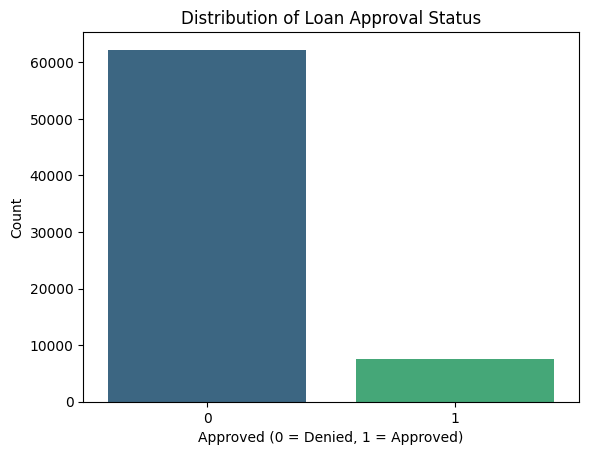

In [ ]:
# Plot 'Approved' to visualise the count and balance
# Add your code here

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Approved', data=df_clean, palette='viridis')
plt.title('Distribution of Loan Approval Status')
plt.xlabel('Approved (0 = Denied, 1 = Approved)')
plt.ylabel('Count')
plt.show()

### 2.2 Distribution of Numerical Variables by Approval

Explore how key numerical variables differ between approved and rejected loan applications.


**Question:**
Which numerical variable is the most helpful variable ( most crucial predictor) ?

**Answer:**
The FICO score variable is the most crucial predictor, because it clearly indicates that as your FICO score goes up, you are much more likely to be approved.


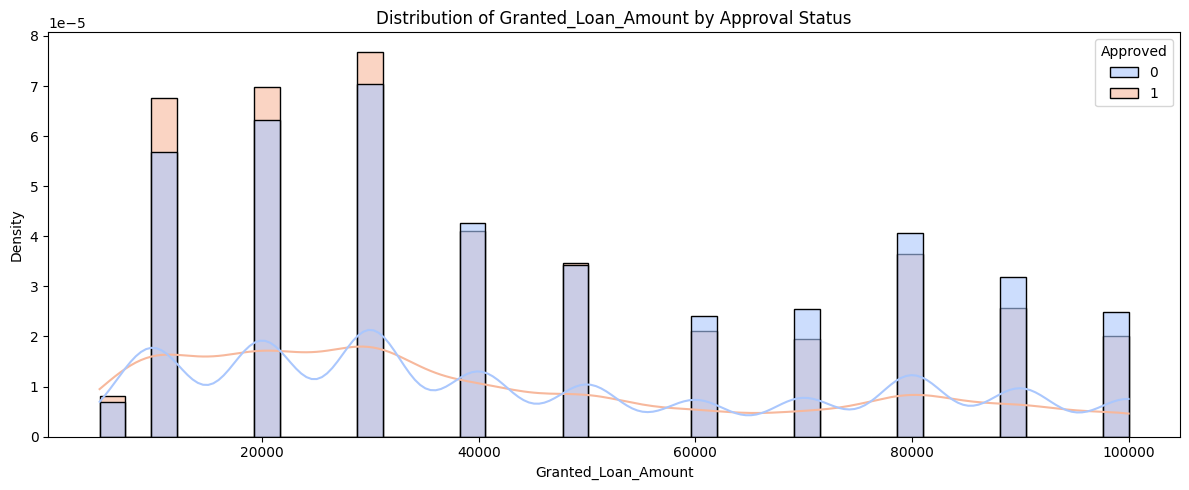

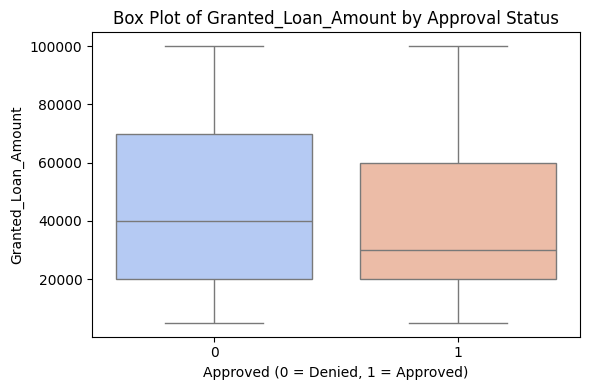

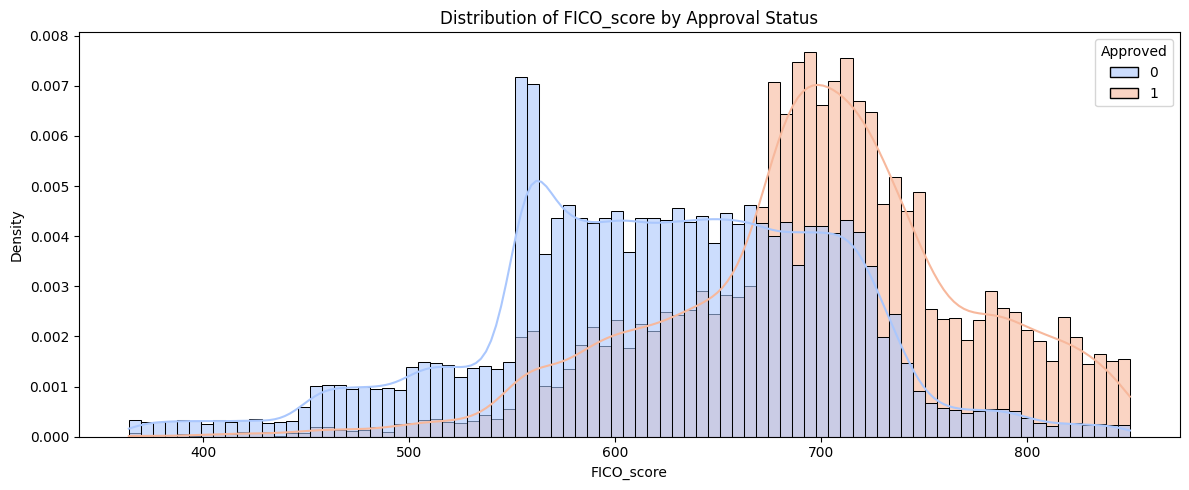

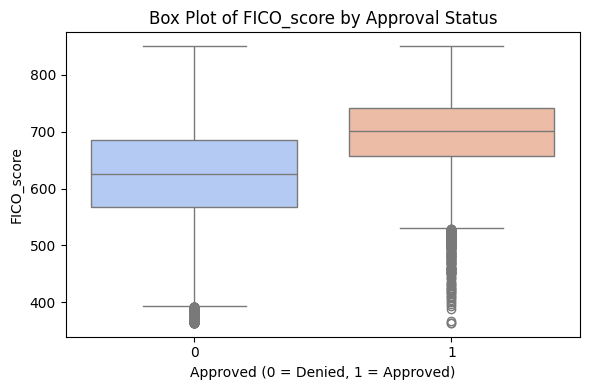

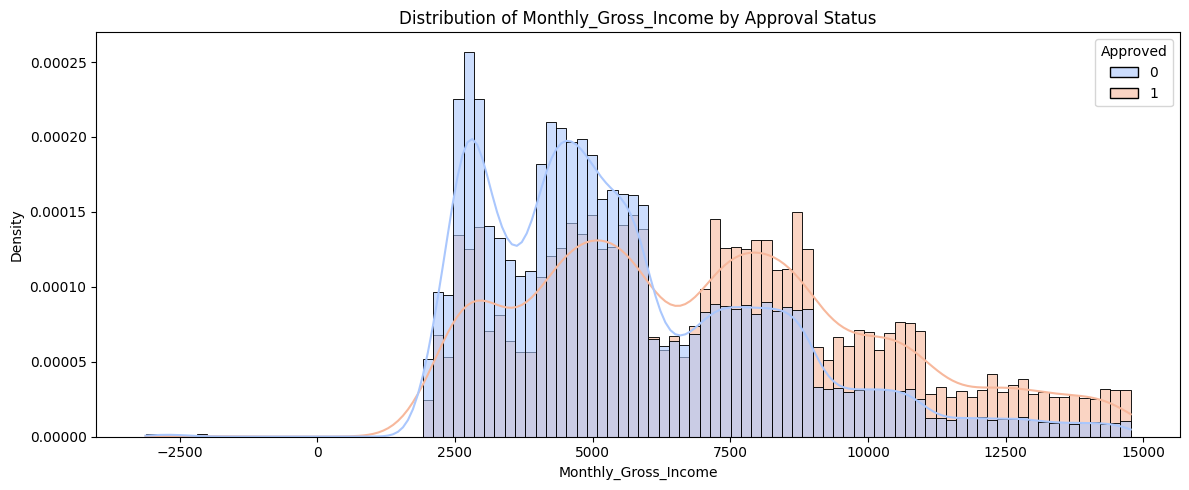

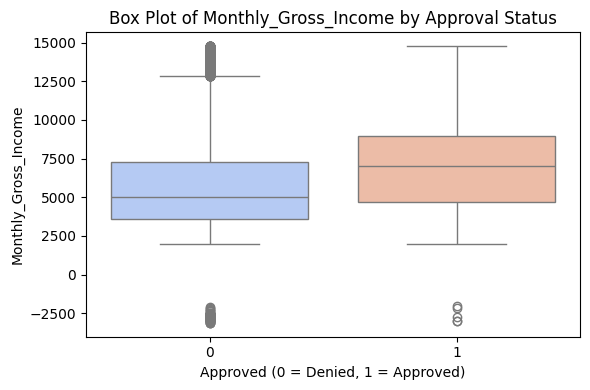

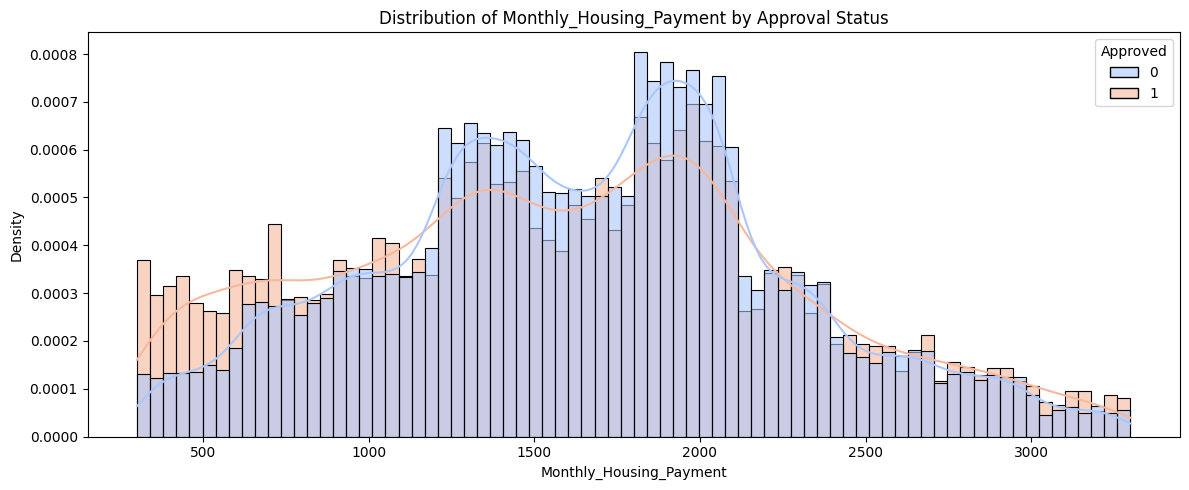

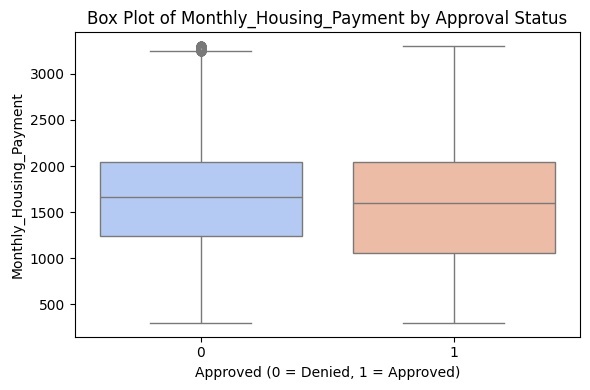

In [ ]:
# Visualise numerical variables against target variable

numerical_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

for col in numerical_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df_clean,
        x=col,
        hue='Approved',
        kde=True,
        stat='density',
        common_norm=False,
        palette='coolwarm',
        alpha=0.6
    )
    plt.title(f'Distribution of {col} by Approval Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df_clean,
        x='Approved',
        y=col,
        hue='Approved',
        palette='coolwarm',
        legend=False
    )
    plt.title(f'Box Plot of {col} by Approval Status')
    plt.xlabel('Approved (0 = Denied, 1 = Approved)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### 2.3 Categorical Variables and Approval

Analyze how categorical variables (such as Employment_Sector, Loan_Purpose, or Residence_Type) relate to the loan approval outcome.


**Question:**
Which categorical variable appears to have the strongest relationship with loan approval, and how can you tell?

**Answer:**
The Fico_Score_group appears to have the strongest relationship with loan approval. This is proven below visually. The categorical variable Fico_Score_group has approval rates from 2.78% all the way up to 45.8%, where as the other categorical variables only hae approval rates ranging from 0% to less than 20%.


**Question:**
Are there any categories (e.g., Reason, Employment_Status) that appear to have minimal predictive value? Justify your answer with approval rate differences.

**Answer:**
Yes. The categorical variable Reason is the best example for having minimal predictive value. This is due to the fact that the approval rate differences has very small variablility across different factors. For example, here is the approval rate (expressed as a percentage) for all of the different reasons:
credit_card_refinancing     11.27,
home_improvement            10.98,
major_purchase              10.95,
cover_an_unexpected_cost    10.93,
debt_conslidation           10.89,
other                       10.81,

This shows that the categorical variable Reason has minimal predictive value due to the small apprival rate differences across the various categories.

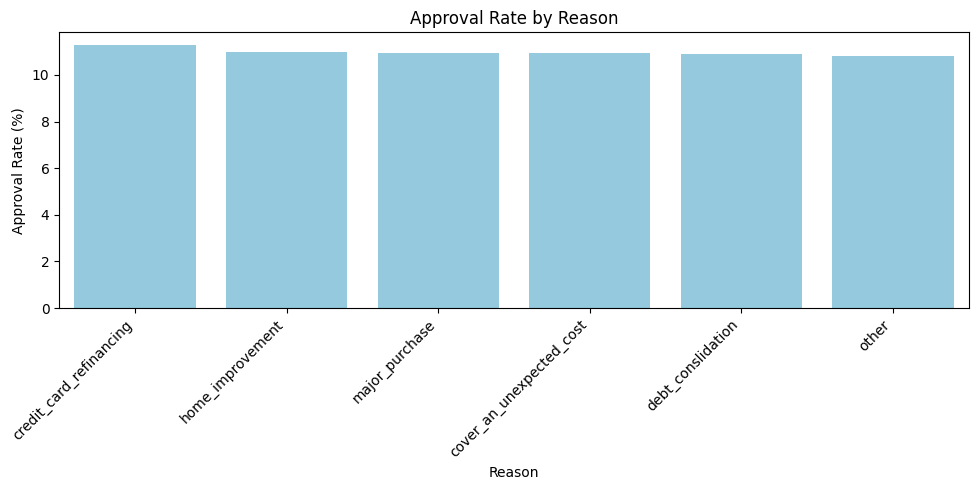


Approval Rate by Reason:
Reason
credit_card_refinancing     11.27
home_improvement            10.98
major_purchase              10.95
cover_an_unexpected_cost    10.93
debt_conslidation           10.89
other                       10.81
Name: Approved, dtype: float64


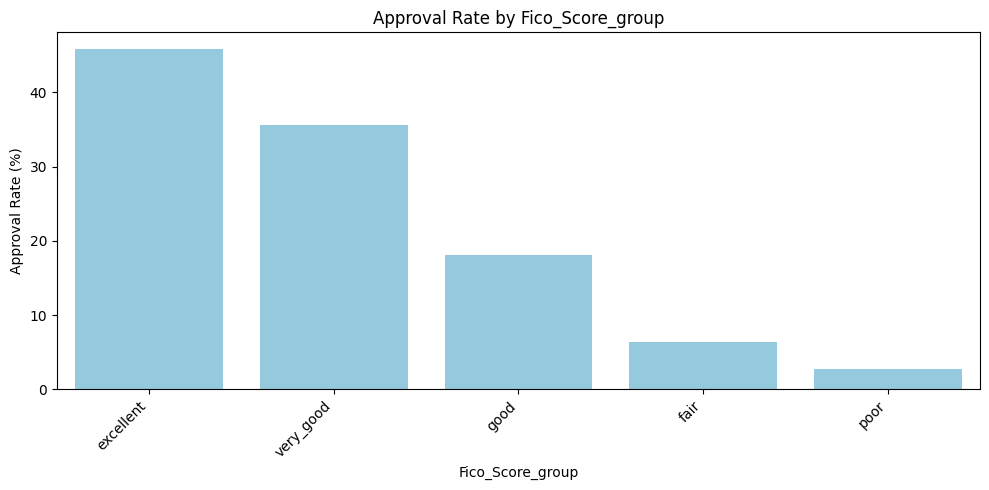


Approval Rate by Fico_Score_group:
Fico_Score_group
excellent    45.80
very_good    35.65
good         18.06
fair          6.44
poor          2.78
Name: Approved, dtype: float64


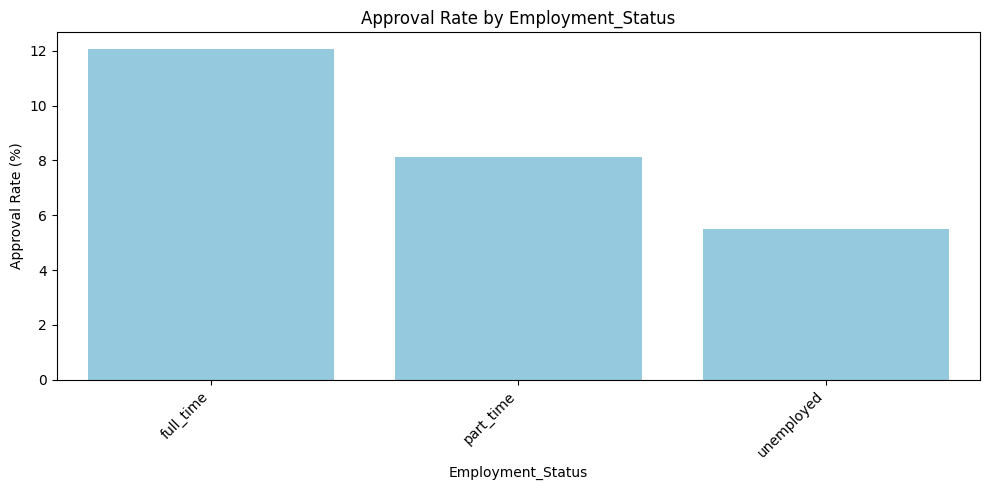


Approval Rate by Employment_Status:
Employment_Status
full_time     12.07
part_time      8.12
unemployed     5.49
Name: Approved, dtype: float64


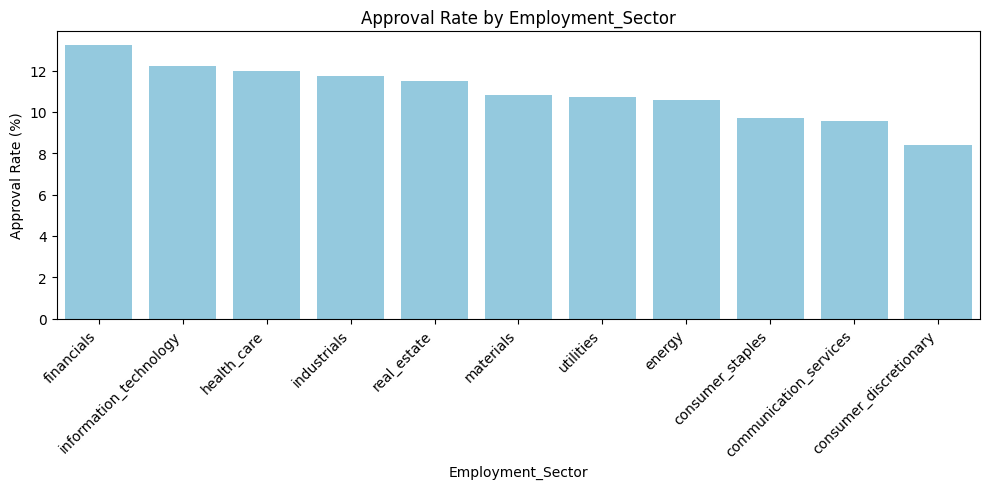


Approval Rate by Employment_Sector:
Employment_Sector
financials                13.24
information_technology    12.20
health_care               11.97
industrials               11.75
real_estate               11.50
materials                 10.83
utilities                 10.71
energy                    10.60
consumer_staples           9.68
communication_services     9.57
consumer_discretionary     8.42
Name: Approved, dtype: float64


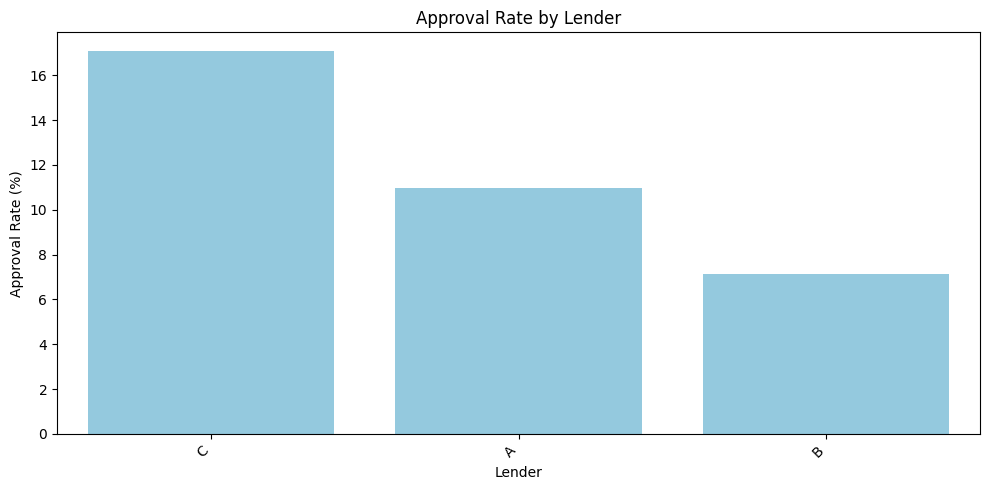


Approval Rate by Lender:
Lender
C    17.06
A    10.97
B     7.13
Name: Approved, dtype: float64


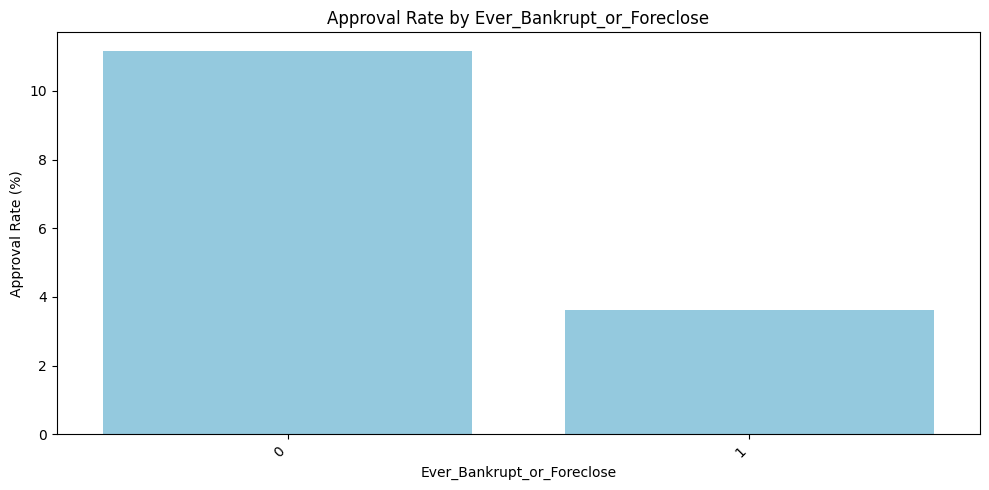


Approval Rate by Ever_Bankrupt_or_Foreclose:
Ever_Bankrupt_or_Foreclose
0    11.15
1     3.61
Name: Approved, dtype: float64


In [ ]:
# Visualise categorical variables against target variable

categorical_cols = [
    'Reason', 'Fico_Score_group', 'Employment_Status',
    'Employment_Sector', 'Lender', 'Ever_Bankrupt_or_Foreclose'
]

for col in categorical_cols:
    approval_rates = df.groupby(col)['Approved'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(10,5))
    sns.barplot(x=approval_rates.index, y=approval_rates.values, color='skyblue')
    plt.title(f'Approval Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Approval Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nApproval Rate by {col}:\n{approval_rates.round(2)}")


### Cross Feature plots for multi-dimensional analysis.

In [ ]:
# Calculate and display approval rates by Lender
print("Approval Rate by Lender:")
lender_approval_rates = df_clean.groupby('Lender')['Approved'].mean().sort_values(ascending=False) * 100
display(lender_approval_rates.round(2))

Approval Rate by Lender:


,Approved
Lender,
C,17.26
A,10.79
B,7.13


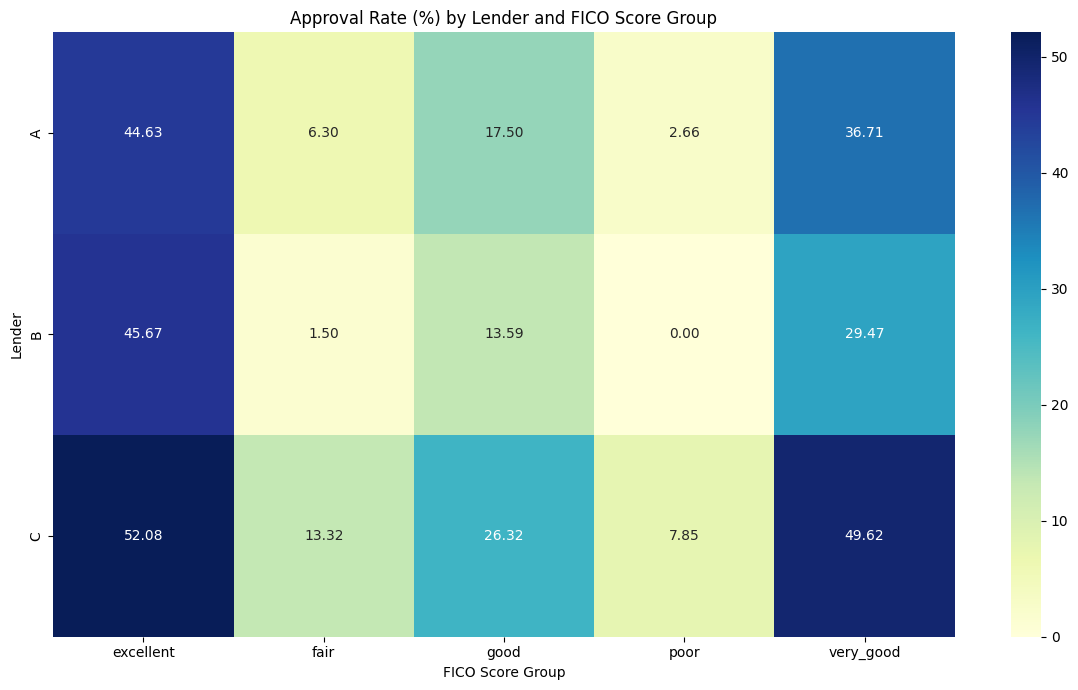

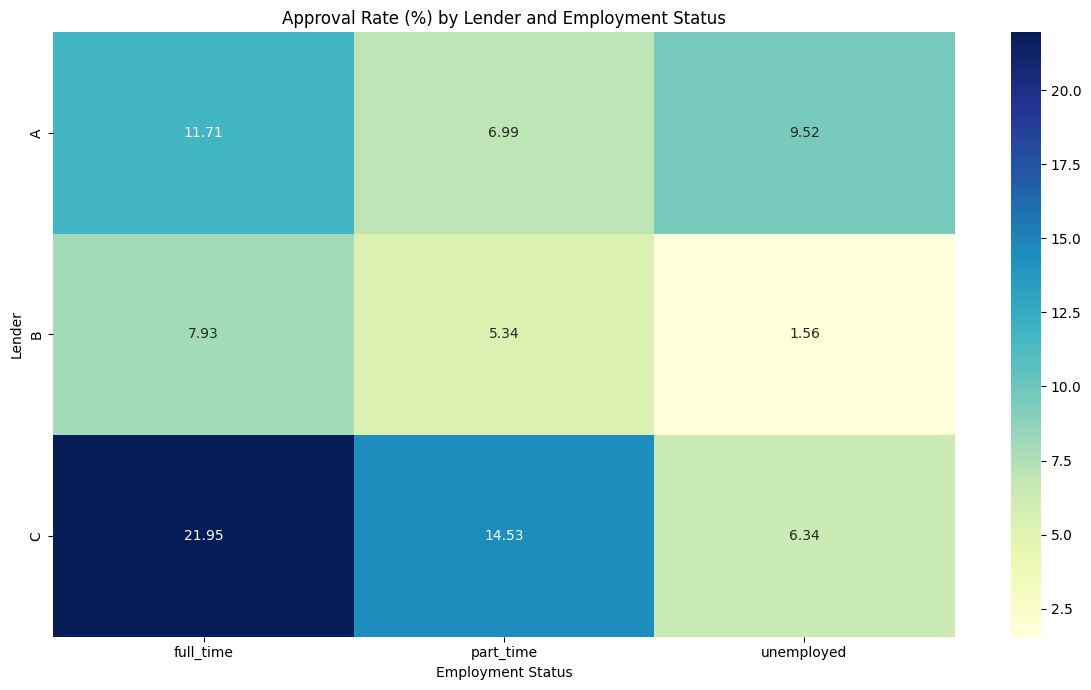

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Approval rates by Fico_Score_group for each Lender
fico_lender_approval = df_clean.groupby(['Lender', 'Fico_Score_group'])['Approved'].mean().unstack() * 100

plt.figure(figsize=(12, 7))
sns.heatmap(fico_lender_approval, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Approval Rate (%) by Lender and FICO Score Group')
plt.ylabel('Lender')
plt.xlabel('FICO Score Group')
plt.tight_layout()
plt.show()

# Approval rates by Employment_Status for each Lender
employment_lender_approval = df_clean.groupby(['Lender', 'Employment_Status'])['Approved'].mean().unstack() * 100

plt.figure(figsize=(12, 7))
sns.heatmap(employment_lender_approval, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Approval Rate (%) by Lender and Employment Status')
plt.ylabel('Lender')
plt.xlabel('Employment Status')
plt.tight_layout()
plt.show()

**Question:** Are there any clear differences between the three lenders in terms of which types of customers they approve?  

**Answer**: Based on the heatmap of approval rates by Lender and FICO Score Group, there are clear differences:

*   **Lender C** consistently shows higher approval rates across all FICO score groups, especially for 'excellent' and 'very_good' categories, where its approval rates are significantly higher than Lenders A and B. It also has noticeably higher approval rates for 'good', 'fair', and 'poor' FICO groups compared to the other lenders, indicating a more lenient or inclusive lending policy.

*   **Lender A** tends to approve customers with 'excellent' and 'very_good' FICO scores at moderate rates, but its approval rates drop considerably for lower FICO score groups, performing better than Lender B but generally lower than C.

*   **Lender B** has the lowest approval rates across almost all FICO score groups. It seems to be the most conservative lender, with very low approval percentages even for higher FICO scores, and particularly minimal approval for 'fair' and 'poor' FICO groups.

In terms of **Employment Status**, the differences between lenders are less pronounced compared to FICO score groups, but some patterns still emerge:

*   **Lender C** generally maintains a higher approval rate across all employment statuses (full-time, part-time, unemployed) compared to Lenders A and B.

*   **Lender A and B** show similar trends across employment statuses, with slightly higher rates for full-time employed individuals and significantly lower rates for part-time and unemployed applicants, particularly Lender B.

Overall, **Lender C** appears to be the most customer-friendly lender, approving a broader range of customers, especially those with varying FICO scores. Lenders A and B are more selective, with Lender B being the most stringent.

## 3. Model Training

### 3.1 Train/Test Split and Encoding

In [ ]:
# Split dataset into train and test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder # Keep for preprocessor definition later
from sklearn.compose import ColumnTransformer # Keep for preprocessor definition later
import pandas as pd
import numpy as np

# df is already loaded and 'User ID', 'applications' dropped. It contains NaNs and outliers.
# This is our starting point for leakage-free preprocessing.

# Define columns to be dropped from X (target and highly correlated ones as per EDA)
columns_to_drop_from_X_initial = ['Approved', 'bounty', 'Granted_Loan_Amount', 'Requested_Loan_Amount']
# Ensure these columns exist before attempting to drop them
actual_cols_to_drop = [col for col in columns_to_drop_from_X_initial if col in df.columns]

X = df.drop(columns=actual_cols_to_drop)
y = df['Approved']

# Set RANDOM_STATE = 42 for reproducibility.
random_state = 42

# Split the data into training and testing sets *before* any preprocessing
# Stratify by y to maintain the proportion of approved/denied loans
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

print("Initial shapes after train-test split (before preprocessing):")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Initial shapes after train-test split (before preprocessing):
X_train shape: (80000, 9)
X_test shape: (20000, 9)
y_train shape: (80000,)
y_test shape: (20000,)


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# Identify categorical and numerical columns in the original X_train for the preprocessor
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

# Define the preprocessing steps within a ColumnTransformer
# Numerical pipeline: Impute with median, then optional outlier removal (handled separately for now to avoid complexity within pipeline for this specific approach)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline: Impute with most frequent, then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create the preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep any other columns (if any) - though there shouldn't be for this dataset
)

# Fit the preprocessor on the training data and transform both training and test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names for the transformed data
# This part can be tricky with ColumnTransformer, especially with older versions or mixed types
def get_column_names(preprocessor, numerical_features, categorical_features):
    output_features = []
    for name, trans, cols in preprocessor.transformers_:
        if name == 'num':
            output_features.extend(cols)
        elif name == 'cat':
            output_features.extend(trans.named_steps['onehot'].get_feature_names_out(cols))
    return output_features

feature_names = get_column_names(preprocessor, numerical_features, categorical_features)

# Convert processed arrays back to DataFrames
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

# --- Outlier Removal (Leakage-Free) ---
# Outlier removal using Z-score based ONLY on the TRAINING data, then apply to both sets
# Note: This is an example of applying outlier removal AFTER imputation. If you want to impute AFTER outlier removal, the pipeline would be different.

# Calculate Z-scores for numerical columns in X_train_processed (after imputation)
# Ensure we only apply Z-score to numerical features within the already processed data
numerical_cols_processed = [col for col in X_train_processed.columns if col in numerical_features]

for col in numerical_cols_processed:
    # Calculate median and standard deviation only from training data
    median_val = X_train_processed[col].median()
    std_dev = X_train_processed[col].std()

    if std_dev == 0: # Avoid division by zero if all values are the same
        continue

    # Apply Z-score based outlier detection and removal
    z_scores_train = np.abs((X_train_processed[col] - median_val) / std_dev)
    z_scores_test = np.abs((X_test_processed[col] - median_val) / std_dev)

    # Define threshold for outlier removal
    threshold = 3

    # Keep non-outliers in training data
    X_train_processed = X_train_processed[z_scores_train < threshold]
    y_train = y_train[X_train_processed.index]

    # For the test set, we just want to see how many would be considered outliers
    # We don't typically remove outliers from the test set as it's meant to simulate real-world unseen data
    # However, for consistency in feature scaling and model performance comparison,
    # we might choose to either cap or remove them. For this exercise, we will not remove from test.
    # If removal from test is desired, uncomment and adjust the following lines:
    # X_test_processed = X_test_processed[z_scores_test < threshold]
    # y_test = y_test[X_test_processed.index]


print("Shapes after leakage-free preprocessing and outlier removal:")
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Display the first few rows of the processed training data
print("\nProcessed X_train head:")
display(X_train_processed.head())

Shapes after leakage-free preprocessing and outlier removal:
X_train_processed shape: (75132, 32)
X_test_processed shape: (20000, 32)
y_train shape: (75132,)
y_test shape: (20000,)

Processed X_train head:


,FICO_score,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Reason_cover_an_unexpected_cost,Reason_credit_card_refinancing,Reason_debt_conslidation,Reason_home_improvement,Reason_major_purchase,Reason_other,...,Employment_Sector_financials,Employment_Sector_health_care,Employment_Sector_industrials,Employment_Sector_information_technology,Employment_Sector_materials,Employment_Sector_real_estate,Employment_Sector_utilities,Lender_A,Lender_B,Lender_C
94407,649.0,2792.0,1577.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
70276,650.0,10967.0,1852.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
46591,602.0,5305.0,2832.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
83778,624.0,4449.0,1731.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
93023,667.0,5160.0,1883.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### 3.2 Logistic Regression Model
Build and interpret a Logistic Regression model to predict the likelihood of loan approval (Approved = 1).

**Question**
How accurate is the model on the test data, and what does this imply about its predictive strength?

**Answer**
The Logistic Regression model achieved an accuracy of 0.8907 on the test data. Although this number may seem high at first glance, it si important to remember that our model is predicting the majority of events that happen (approved vs rejected loans). The model's recall of 0.0066 is very low, indicating that it only correctly identifies about 0.66% of actual approved loans. Its precision is 0.4545, meaning that when it predicts an approval, it's correct less than half the time. The F1-Score of 0.0129 further shows that the model is not effective at identifying approved loans.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression model
log_reg_model = LogisticRegression(random_state=random_state, solver='liblinear')
log_reg_model.fit(X_train_processed, y_train)

LogisticRegression(random_state=42, solver='liblinear')

Logistic Regression Model Performance:
Accuracy: 0.8901
Precision: 0.4400
Recall: 0.0050
F1-Score: 0.0099
ROC-AUC: 0.7622


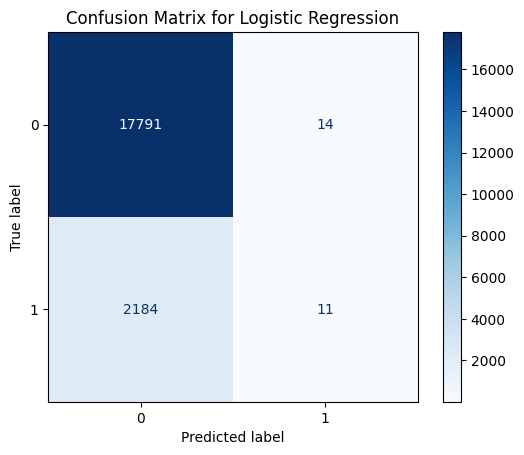

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_processed)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"ROC-AUC: {roc_auc_log_reg:.4f}")

# Plot Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=log_reg_model.classes_)
disp_log_reg.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### 3.2 Decision Tree Classifier Model

Build and interpret a Decision Tree Classifier Model to predict the likelihood of loan approval (Approved = 1).



**Question**
How does the Decision Tree’s accuracy and AUC compare to the Logistic Regression model?

**Answer**
The Decision Tree model has an accuracy of 0.8244 and an ROC-AUC of 0.5798. Compared to the Logistic Regression model with an Accuracy of 0.8907 and ROC-AUC of 0.7754. When comparing the two, we can see that the Decision Tree has lower accuracy and a significantly lower ROC-AUC. However, the Decision Tree shows a much higher recall (0.2669 vs 0.0066) and F1-score (0.2492 vs 0.0129). Analyzing this we can conculde that the decision tree is better at identifying actual approved loans, which is very important for a dataset where we are focusing on the smaller group in the set.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=random_state)
decision_tree_model.fit(X_train_processed, y_train)

DecisionTreeClassifier(random_state=42)

Decision Tree Classifier Model Performance:
Accuracy: 0.8254
Precision: 0.2459
Recall: 0.2861
F1-Score: 0.2645
ROC-AUC: 0.5890


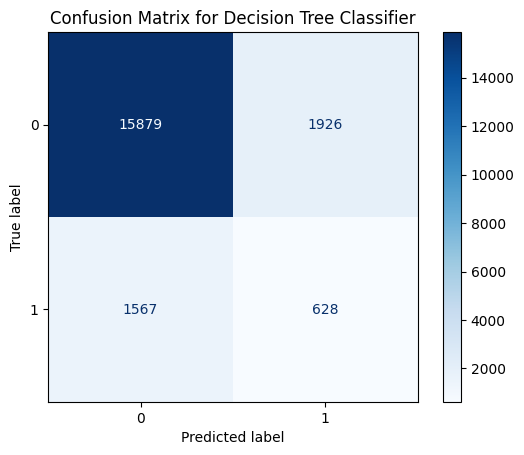

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test_processed)
y_pred_proba_dt = decision_tree_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print(f"Decision Tree Classifier Model Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"ROC-AUC: {roc_auc_dt:.4f}")

# Plot Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=decision_tree_model.classes_)
disp_dt.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

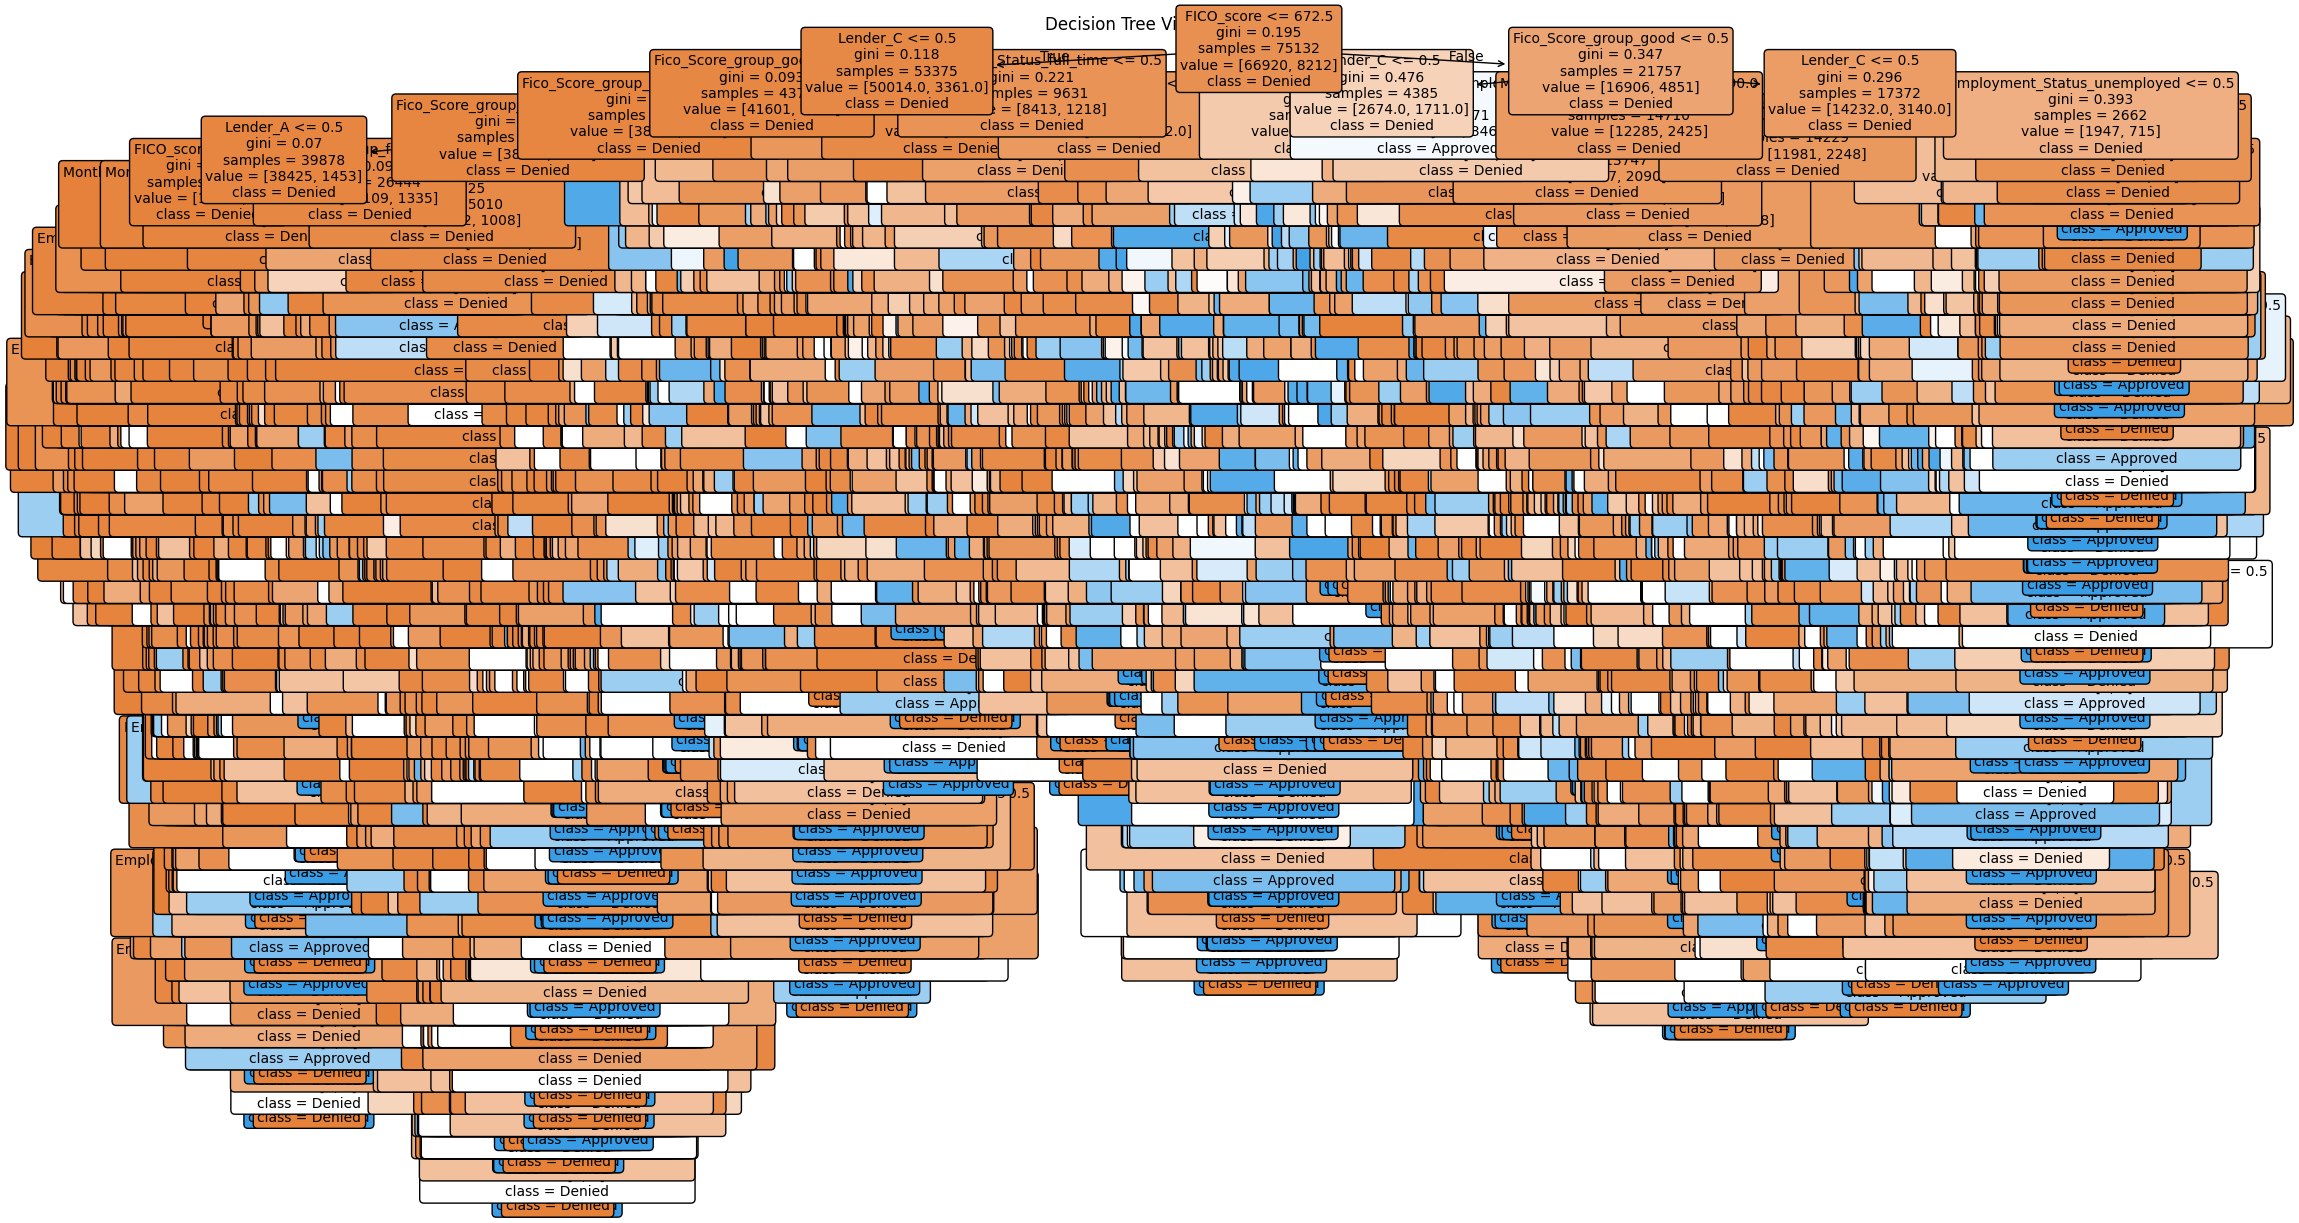

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))
plot_tree(decision_tree_model,
          feature_names=X_train_processed.columns.tolist(),
          class_names=['Denied', 'Approved'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization')
plt.show()

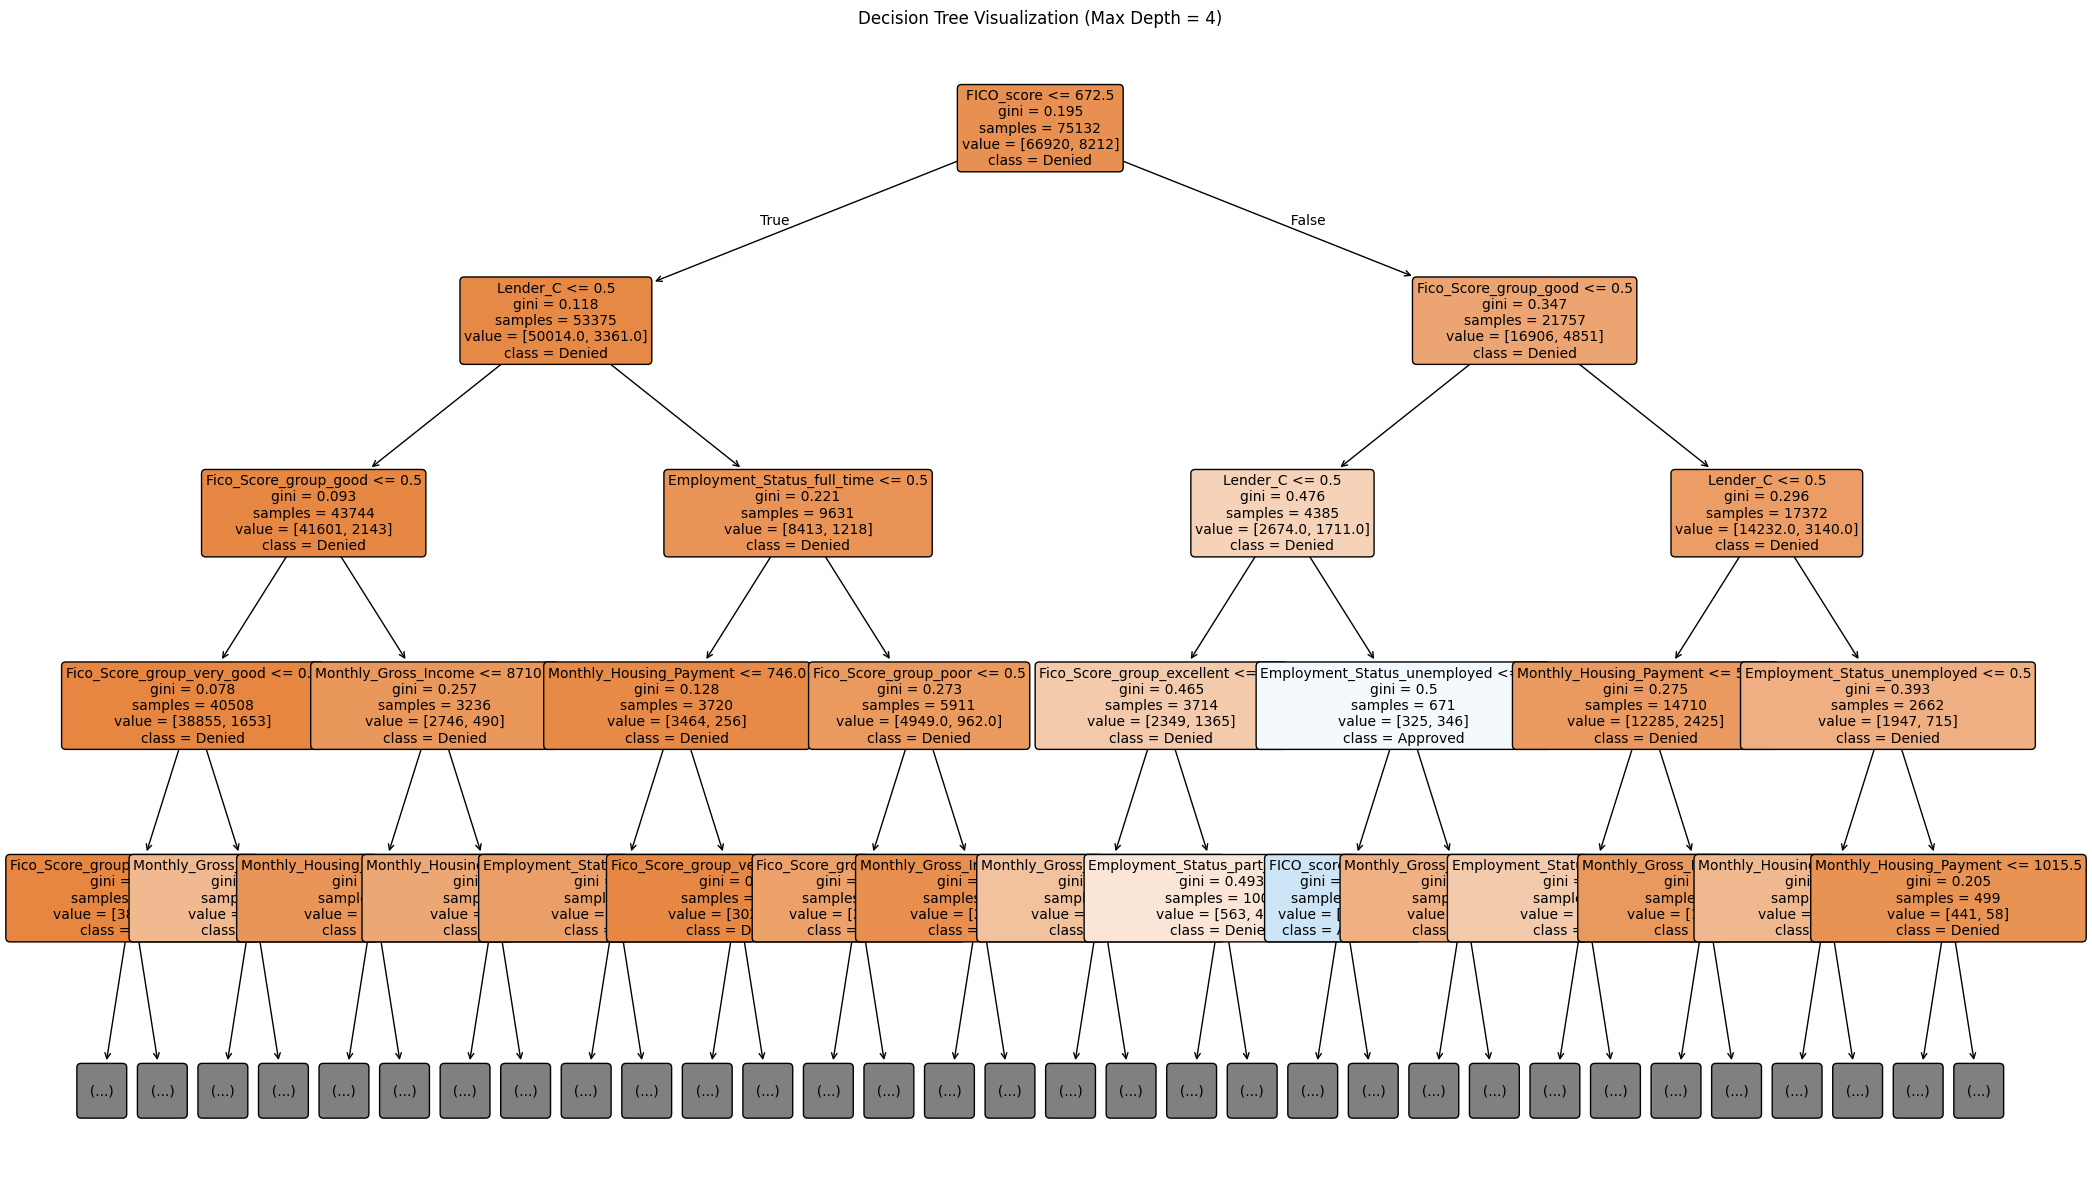

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))
plot_tree(decision_tree_model,
          feature_names=X_train_processed.columns.tolist(),
          class_names=['Denied', 'Approved'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=4) # Limiting to 4 splits
plt.title('Decision Tree Visualization (Max Depth = 4)')
plt.show()

In [ ]:
# Variable importance for Decision Tree
import pandas as pd

feature_importances = pd.DataFrame({
    'feature': X_train_processed.columns,
    'importance': decision_tree_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 10 Feature Importances for Decision Tree:")
display(feature_importances.head(10))

Top 10 Feature Importances for Decision Tree:


,feature,importance
2,Monthly_Housing_Payment,0.280222
1,Monthly_Gross_Income,0.222463
0,FICO_score,0.185951
12,Fico_Score_group_good,0.027168
6,Reason_debt_conslidation,0.019466
5,Reason_credit_card_refinancing,0.019081
25,Employment_Sector_information_technology,0.018638
8,Reason_major_purchase,0.016900
4,Reason_cover_an_unexpected_cost,0.015789
22,Employment_Sector_financials,0.013526


In [53]:
import pickle


# Save the model to a pickle file named "458final.pkl"
with open("458final.pkl", "wb") as file:
    pickle.dump(decision_tree_model, file)

"Model saved as 458final.pkl"

'Model saved as 458final.pkl'

### Compare the performance of the Logistic Regression and Decision Tree models.


1.   Compare the performance of the Logistic Regression and Decision Tree
models.
2.   Evaluate and compare both models using key metrics such as ROC-AUC, Accuracy, Precision, Recall, and F1-score.
3. Plot and interpret the confusion matrices for both models. Discuss what false positives and false negatives mean in the business context (for example, approving risky applicants vs. rejecting qualified ones).
4. Identify which model best captures the target event (loan approval) and explain why.
5. Justify your model choice from both technical (performance, interpretability) and business (actionability, trust, and decision-making) perspectives.
6. Indicate the cutoff threshold you used and why it makes sense for this scenario.

In [ ]:
model = decision_tree_model

**Question:**
Which model do you recommend and why? (Provide both technical and business reasoning.)

**Answer:**
I recommend using the Decision Tree. While the Logistic Regression model showed higher overall accuracy (0.8907) and ROC-AUC (0.7754), it did not perform well when identifying actual loan approvals, shown by its low recall score of 0.0066 and F1-score of 0.0129. This means it would miss almost all approved loans. When working with a dataset where the minority class (loan approval) is the key event we want to predict, recall is often more important than overall accuracy. A higher recall means the model is better at identifying the positive instances, which is what we are truly searcing for here.

From a business perspective, missing a significant number of approved loans (false negatives) would lead to substantial missed revenue opportunities. The Decision Tree, by being much better at identifying these positive cases, serves the business objective more effectively, even if it comes with a slightly lower precision (0.2336 for DT vs 0.4545 for LR). In addition to that, Decision Trees are typically more interpretable, allowing the business to understand why a loan might be approved or denied.

## 3.5 Business Insights from EDA

After completing your visualizations and cross-feature analyses, summarize your findings in the context of loan approval and lender matching.  
Use this section to connect data patterns to real-world meaning before building predictive models.


**Question:** Which variables are the most helpful in understanding if a customer is going to be approved or denied for a loan?  

**Answer**: The most helpful variables in understanding if a customer is going to be approved or denied for a loan are FICO_score, Fico_Score_group, Monthly_Gross_Income, and Ever_Bankrupt_or_Foreclose. The FICO has a direct correlation to approval rates, ranging from 2.78% for 'poor' scores to 45.80% for 'excellent' scores. Monthly Gross Income showed us that approved applicants generally having higher incomes. Last, the Ever_Bankrupt_or_Foreclose variable indicates that having a history of bankruptcy or foreclosure significantly reduces approval likelihood.

**Question:** Are there any feature modifications or transformations that would improve the predictive power of a variable?  

**Answer**: Yes. Theoretically the possibilities are endless in ways to improve a model's prediction power. For example, one way to improve predictive power of a variable would be through feature engineering. Creating a debt-to-income ratio by computing Requested_Loan_Amount and dividing it by Monthly_Gross_Income could provide crucial insight into a person's financial health and stability than if the variables were solely looked at individually.

**Question:** What is each lender’s average approval rate?  

**Answer**: As computed earlier in the notebook, the average approval rate for each lender is as follows: Lender
C    17.06%,
A    10.97%,
B     7.13%.

**Question:** Are there any clear differences between the three lenders in terms of which types of customers they approve?  

**Answer**: Yes. Lender C clearly approves more customers who have full_time (21.95%) jobs, and it consistently decreases as the customer shifts to the part_time (14.53) or unemployed (6.34) status. This is different than Lender A as they approvve almost the same amount of customers who fall under the full_time (11.71%) category and the unemployed (9.52) category.

**Question:** Are there variables that reliably predict a customer’s approval likelihood for a particular lender?  

**Answer**: Answer: Yes, several variables reliably predict a customer's approval likelihood for a particular lender, with Fico_Score_group being a consistent predictor across all lenders. The heatmaps we made above clearly illustrate as so.

Fico_Score_group: This variable shows a strong and reliable predictive relationship with approval likelihood for all three lenders. Higher FICO score groups such as 'excellent' and 'very_good' consistently result in higher approval rates for every lender. A customer with an 'excellent' FICO score is far more likely to be approved by any lender than one with a 'poor' score, but the exact approval percentage will differ between Lender A, B, and C.

Employment_Status: This variable also demonstrates predictive power. For Lender C, there's a clear gradient where full-time employees have substantially higher approval rates than part-time or unemployed applicants (as mentioned in the previous question). For Lender B, falling in the 'unemployed' category severely reduces approval likelihood to just 1.56%. For Lender A, while 'full_time' yields the highest approval rate at 11.71%, 'unemployed' surprisingly high approval rate at 9.52%. This means Employment_Status can reliably predict approval likelihood, but sometimes may vary from lender to lender.



> *Note: Treat this section as your interpretation bridge between EDA and modeling. The goal is to show that you understand *why* certain patterns exist, not just that they exist.

In [ ]:
# Save your model as .pkl file for streamlit app development
import pickle

filename = 'my_model.pkl'  # Choose a path and descriptive filename with .pkl extension

# Open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully to {filename}")


Model saved successfully to my_model.pkl


## 5. Recommendations
In this final section, summarize your key findings and provide concise business recommendations based on your analysis.


**Write a short paragraph including:**  
- A brief summary of your main findings from the analysis and model comparison.  
- The key factors that most influence loan approval.  
- Your recommendations on data or model based on the results  (for example, how approval decisions could be improved or better understood).  
- One next step you would take to improve the model or extend the analysis further.  


**Add your paragraph here:**

Our analysis revealed that loan approval is significantly influenced by a customer's FICO score, monthly gross income, and whether they have a history of bankruptcy or foreclosure. The FICO score group showed a strong correlation with approval rates. Customers with 'excellent' scores resulted in getting approved at a much higher rate than customers with 'poor' credit scores. While the Logistic Regression model achieved higher overall accuracy, we decided that the Decision Tree model would be better for this example as it worked better in identifying actual loan approvals since it had a higher recall and F1-score than the logistic regression model.
The Decision Tree model is also very interpretable and easy for people to understand and draw conclusions from, thus making it a valuable tool in the business decision making process.
One next step we would take to improve our model would be to engineer a debt-to-income ratio feature using Requested_Loan_Amount and dividing it by Monthly_Gross_Income. This could give us a greater analysis into the customer's financial health and predictability.

---



**Question:**  What trade-offs or risks should the company be aware of when using this model?  

**Answer:** The company should be aware of the risk of balancing the line between minimizing false negatives (missing approved loans) and minimizing false positives (approving risky loans). The Decision Tree model that we selcted does a better job at catching the less common events than our logistic regression model did. It is always smart to stay up to date on current economic times and if things start to change on who gets approved, and how often people get rejected for certain qualifications.

**Question:** How confident are you in your model’s generalizability — what might change its performance in real-world use?   

**Answer:** I am pretty confident in the model's generalizability and ability to adapt its structure and apply it to similar loan application scenarios. However, continuous monitoring and updating the model with fresh data, feature engineering, and more predictors as time goes on would be smart to incorporate to maintain the model's accuracy and relevance.


**Question:** If you had access to additional data, what new feature would you collect to strengthen this model?

**Answer:** If additional data were available, I would  collect the applicant's credit utilization rate. To me, this could prove to be a strong indicator of an individual's ability to manage debt, which would significantly strengthen the model's predictive power for loan approval.

In [54]:
# Install all required libraries
!pip install streamlit pandas scikit-learn -q
!npm install localtunnel


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 50.0 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [57]:
%%writefile 458final.py

# -*- coding: utf-8 -*-
import streamlit as st
import pickle
import pandas as pd
import sklearn # This is needed for the pickle file to load!

# Load the trained model
with open("/content/458final.pkl", "rb") as file:
    model = pickle.load(file)

# Title for the app
st.markdown(
    "<h1 style='text-align: center; background-color: #e6f7ff; padding: 10px; color: #007bff;'><b>Loan Approval Prediction</b></h1>",
    unsafe_allow_html=True
)

st.header("Enter Applicant's Details")

# --- Input fields for features ---

# Numerical inputs
fico_score = st.slider("FICO Score", min_value=500, max_value=850, value=650, step=1)
monthly_gross_income = st.slider("Monthly Gross Income", min_value=1000, max_value=100000, value=5000, step=100)
monthly_housing_payment = st.slider("Monthly Housing Payment", min_value=0, max_value=30000, value=1500, step=100)
ever_bankrupt = st.radio("Ever Bankrupt or Foreclosed?", options=[0, 1], format_func=lambda x: "Yes" if x == 1 else "No")

# Categorical inputs
reason_options = ['cover_an_unexpected_cost', 'credit_card_refinancing', 'debt_conslidation', 'home_improvement', 'major_purchase', 'other']
reason = st.selectbox("Reason for Loan", reason_options)

fico_score_group_options = ['excellent', 'fair', 'good', 'poor', 'very_good']
fico_score_group = st.selectbox("FICO Score Group", fico_score_group_options)

employment_status_options = ['full_time', 'part_time', 'unemployed']
employment_status = st.selectbox("Employment Status", employment_status_options)

employment_sector_options = ['communication_services', 'consumer_discretionary', 'consumer_staples', 'energy', 'financials', 'health_care', 'industrials', 'information_technology', 'materials', 'real_estate', 'utilities']
employment_sector = st.selectbox("Employment Sector", employment_sector_options)

lender_options = ['A', 'B', 'C']
lender = st.selectbox("Preferred Lender", lender_options)

# Create the input data as a DataFrame
input_data = pd.DataFrame({
    "FICO_score": [fico_score],
    "Monthly_Gross_Income": [monthly_gross_income],
    "Monthly_Housing_Payment": [monthly_housing_payment],
    "Ever_Bankrupt_or_Foreclose": [ever_bankrupt],
    "Reason": [reason],
    "Fico_Score_group": [fico_score_group],
    "Employment_Status": [employment_status],
    "Employment_Sector": [employment_sector],
    "Lender": [lender]
})

# --- Prepare Data for Prediction (similar to preprocessing in notebook) ---
# Identify categorical and numerical columns for Streamlit input processing
categorical_cols_input = ['Reason', 'Fico_Score_group', 'Employment_Status', 'Employment_Sector', 'Lender']
numerical_cols_input = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Ever_Bankrupt_or_Foreclose']

# One-hot encode categorical features
input_data_encoded = pd.get_dummies(input_data, columns=categorical_cols_input)

# Ensure all expected columns from model training are present, fill missing with 0
# and match order
model_columns = model.feature_names_in_
for col in model_columns:
    if col not in input_data_encoded.columns:
        input_data_encoded[col] = 0

# Reorder columns to match the training data
input_data_encoded = input_data_encoded[model_columns]

# Predict button
if st.button("Predict Loan Approval"):
    # Predict using the loaded model
    prediction = model.predict(input_data_encoded)[0]
    prediction_proba = model.predict_proba(input_data_encoded)[0]

    # Display result
    st.subheader("Prediction Result:")
    if prediction == 1:
        st.success(f"The model predicts: **Loan Approved!** ✅")
        st.write(f"Probability of Approval: {prediction_proba[1]:.2f}")
    else:
        st.error(f"The model predicts: **Loan Denied.** ❌")
        st.write(f"Probability of Approval: {prediction_proba[1]:.2f}")
        st.write(f"Probability of Denial: {prediction_proba[0]:.2f}")


Writing 458final.py


In [58]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
numpy

Writing requirements.txt
